# 3.1 정확도

정확도는 실제 데이터에서 예측데이터가 얼마나 같은 지를 판단하는 지표
이진분류 데이터 구성에 따라 ML모델 성능을 왜곡할 수 있어 정확도 수치 하남나 가지고 성능을 평가 하지 않음
데이터 분포도가 균일하지 x-> 높은 수치 나타날 수 있음

In [6]:
from sklearn.base import BaseEstimator
class MyDummyClassifier(BaseEstimator):
    def fit(self,X,y=None):
        pass
    def predict(self,X):
        pred=np.zeros((X.shape[0],1))
        for i in range(X.shape[0]):
            if X['Sex'].iloc[i]==1:
                pred[i]=0
            else:
                pred[i]=0
        return pred

In [7]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd


In [8]:
class MyFakeClassifier(BaseEstimator):
    def fit(self,X,y):
        pass
    def predict(self,X):
        return np.zeros((len(X),1),dtype=bool)
digits=load_digits()
y=(digits.target==7).astype(int)
X_train,X_test,y_train,y_test=train_test_split(digits.data,y,random_state=11)

In [9]:
print('레이블 테스트 세트 크기:',y_test.shape)
print('테스트 세트 레이블 0과 1의 분포도')
print(pd.Series(y_test).value_counts())

fakeclf=MyFakeClassifier()
fakeclf.fit(X_train,y_train)
fakepred=fakeclf.predict(X_test)
print('모든 예측을 0으로 하여도 정확도는 :{:.3f}'.format(accuracy_score(y_test,fakepred)))

레이블 테스트 세트 크기: (450,)
테스트 세트 레이블 0과 1의 분포도
0    405
1     45
Name: count, dtype: int64
모든 예측을 0으로 하여도 정확도는 :0.900


- 오차행렬 : 학습된 분류 모델이 예측을 수행하면서 얼마나 헷갈리고 있는 지 함께 보여준ㄴ 지표
- TN,FP,FN,FP

In [10]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,fakepred)

array([[405,   0],
       [ 45,   0]], dtype=int64)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)  #
    recall = recall_score(y_test, pred)
    
    print('오차 행렬')
    print(confusion)
    print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}')

In [17]:
def transform_features(df):
    # 예: 결측치 처리, 인코딩, 스케일링 등 포함
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Embarked'].fillna('S', inplace=True)
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    return df


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

titanic_df=pd.read_csv('train.csv')
y_titanic_df=titanic_df['Survived']
X_titanic_df=titanic_df.drop('Survived',axis=1)
X_titanic_df=transform_features(X_titanic_df)

X_train,X_test,y_train,y_test=train_test_split(X_titanic_df,y_titanic_df,
                                               test_size=0.20,random_state=11)
lr_clf=LogisticRegression(solver='liblinear')
lr_clf.fit(X_train,y_train)
pred=lr_clf.predict(X_test)
get_clf_eval(y_test,pred)

오차 행렬
[[105  13]
 [ 12  49]]
정확도: 0.8603, 정밀도: 0.7903, 재현율: 0.8033


In [19]:
def transform_features(df):
    df['Cabin'] = df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Embarked'].fillna('S', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    # 불필요한 문자형 컬럼 제거
    drop_cols = ['Name', 'Ticket']  # 또는 'PassengerId'도 포함 가능
    df.drop(columns=drop_cols, inplace=True)
    
    return df


정밀도/재현율 트레이드 오프 - 상호 보완적인 평가 지표(한쪽 높이면 다른쪽 수치 떨어짐)

In [21]:
pred_proba=lr_clf.predict_proba(X_test)
pred=lr_clf.predict(X_test)
print('pred_proba()결과 Shape:{0}'.format(pred_proba.shape))
print('pred_proba array에서 앞 3개만 샘플로 추출\n:',pred_proba[:3])
pred_proba_result=np.concatenate([pred_proba,pred.reshape(-1,1)],axis=1)
print('두개의 class중에서 더 큰 확률을 클래스 값으로 예측\n',pred_proba_result[:3])

pred_proba()결과 Shape:(179, 2)
pred_proba array에서 앞 3개만 샘플로 추출
: [[0.46317773 0.53682227]
 [0.87051143 0.12948857]
 [0.84234268 0.15765732]]
두개의 class중에서 더 큰 확률을 클래스 값으로 예측
 [[0.46317773 0.53682227 1.        ]
 [0.87051143 0.12948857 0.        ]
 [0.84234268 0.15765732 0.        ]]


첫번째+두번째 칼럼값 더하면 1이됨, 칼럼 중 더 큰확률값으로 predict메서드가 최종 예측함

In [22]:
from sklearn.preprocessing import Binarizer
X=[[1,-1,2],
   [2,0,0],
   [0,1.1,1.2]]
binarizer=Binarizer(threshold=1.1)
print(binarizer.fit_transform(X))

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


threshold값이 1.1보다 작으면 0,크면1로 변환됨

In [24]:
from sklearn.preprocessing import Binarizer
custom_threshold=0.5
pred_proba_1=pred_proba[:,1].reshape(-1,1)
binarizer=Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict=binarizer.transform(pred_proba_1)
get_clf_eval(y_test,custom_predict)

오차 행렬
[[105  13]
 [ 12  49]]
정확도: 0.8603, 정밀도: 0.7903, 재현율: 0.8033


분결정 임계값 낮출때(0.4로)

In [26]:
custom_threshold=0.4
pred_proba_1=pred_proba[:,1].reshape(-1,1)
binarizer=Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict=binarizer.transform(pred_proba_1)
get_clf_eval(y_test,custom_predict)

오차 행렬
[[100  18]
 [ 10  51]]
정확도: 0.8436, 정밀도: 0.7391, 재현율: 0.8361


재현율 값이 올라가고 정밀도가떨어짐(positive예측값을 결정하는 확률의 기준이 되는데 0.4부터 positive예측ㅇ르 너그럽게해서 임계값낮추면 true값이 많아지게됨) 

In [30]:
from sklearn.metrics import precision_recall_curve
pred_proba_class1=lr_clf.predict_proba(X_test)[:,1]
precision,recalls,thresholds=precision_recall_curve(y_test,pred_proba_class1)
thr_index=np.arange(0,thresholds.shape[0],15)
print('샘플추출을 위한 임계값 배열의 index 10개:',thr_index)
print('샘플용 10개의 임곗값:',np.round(thresholds[thr_index],2))
print('샘플 임곗값별정밀도:',np.round(precision[thr_index],3))
print('샘플 임곗값별 재현율:',np.round(recalls[thr_index],3))

샘플추출을 위한 임계값 배열의 index 10개: [  0  15  30  45  60  75  90 105 120 135 150 165]
샘플용 10개의 임곗값: [0.01 0.09 0.11 0.12 0.14 0.16 0.25 0.39 0.53 0.65 0.77 0.91]
샘플 임곗값별정밀도: [0.341 0.372 0.396 0.44  0.479 0.538 0.618 0.716 0.814 0.932 0.966 1.   ]
샘플 임곗값별 재현율: [1.    1.    0.967 0.967 0.934 0.918 0.902 0.869 0.787 0.672 0.459 0.23 ]


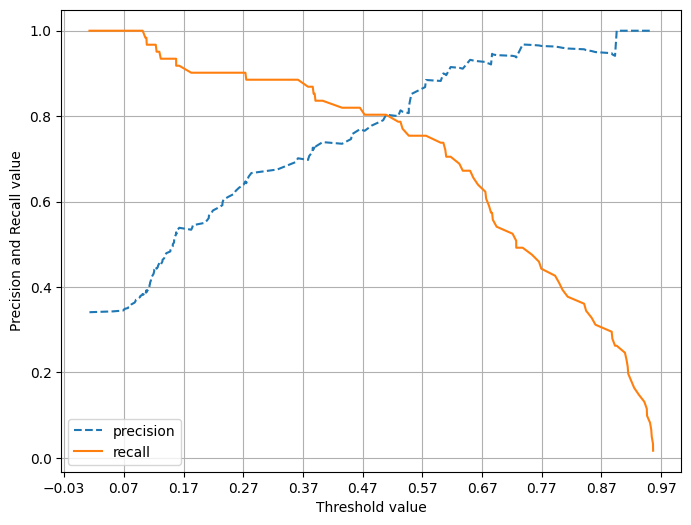

In [38]:
def precision_recall_curve_plot(y_test,pred_proba_c1):
    precisions,recalls,thresholds=precision_recall_curve(y_test,pred_proba_c1)

    plt.figure(figsize=(8,6))
    
    threshold_boundary=thresholds.shape[0]
    plt.plot(thresholds,precisions[0:threshold_boundary],linestyle='--',label='precision')
    plt.plot(thresholds,recalls[0:threshold_boundary],label='recall')
    start,end=plt.xlim()
    plt.xticks(np.round(np.arange(start,end,0.1),2))
    plt.xlabel('Threshold value');plt.ylabel('Precision and Recall value')
    plt.legend();plt.grid()
    plt.show()

precision_recall_curve_plot(y_test,lr_clf.predict_proba(X_test)[:,1])

f1스코어는 정밀도와 재현율을 결합한 지표: 정밀도,재현율이 어느쪽으로 치우치징낳은 수치를 나타낼때 높은 값을 가짐

In [39]:
from sklearn.metrics import f1_score
f1=f1_score(y_test,pred)
print('F1스코어:{0:.4f}'.format(f1))

F1스코어:0.7967


In [48]:
def get_clf_eval(y_test,pred):
    confusion=confusion_matrix(y_test,pred)
    accuracy=accuracy_score(y_test,pred)
    precision=precision_score(y_test,pred)
    recall=recall_score(y_test,pred)
    f1=f1_score(y_test,pred)
    print('오차 행렬')
    print(confusion)
    print('정확도:{0:.4f},정밀도:{1:.4f},재현율:{2:.4f},F1:{3:.4f}'.format(accuracy,precision,recall,f1))

thresholds=[0.4,0.45,0.5,0.55,0.60]
pred_proba=lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test,pred_proba[:,1].reshape(-1,1),thresholds)

임계값: 0.40, 정확도: 0.8436, 정밀도: 0.7391, 재현율: 0.8361, F1: 0.7846
임계값: 0.45, 정확도: 0.8436, 정밀도: 0.7463, 재현율: 0.8197, F1: 0.7813
임계값: 0.50, 정확도: 0.8603, 정밀도: 0.7903, 재현율: 0.8033, F1: 0.7967
임계값: 0.55, 정확도: 0.8715, 정밀도: 0.8519, 재현율: 0.7541, F1: 0.8000
임계값: 0.60, 정확도: 0.8771, 정밀도: 0.8824, 재현율: 0.7377, F1: 0.8036


In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):
    for custom_threshold in thresholds:
        binarized = (pred_proba_c1 >= custom_threshold).astype(int)
        accuracy = accuracy_score(y_test, binarized)
        precision = precision_score(y_test, binarized)
        recall = recall_score(y_test, binarized)
        f1 = f1_score(y_test, binarized)
        print('임계값: {:.2f}, 정확도: {:.4f}, 정밀도: {:.4f}, 재현율: {:.4f}, F1: {:.4f}'.format(
            custom_threshold, accuracy, precision, recall, f1
        ))


ROC곡선 - 수신자 판단 곡선

In [52]:
from sklearn.metrics import roc_curve
pred_proba_class1=lr_clf.predict_proba(X_test)[:,1]
fprs,tprs,thresholds=roc_curve(y_test,pred_proba_class1)
thr_index=np.arange(1,thresholds.shape[0],5)
print('샘플추출을 위한 임곘값 배열의 index:',thr_index)
print('샘플 index로 추출한 임곗값:',np.round(thresholds[thr_index],2))
print('샘플 임곗값별 FPR:',np.round(fprs[thr_index],3))
print('샘플 임곗값별TPR:',np.round(tprs[thr_index],3))

샘플추출을 위한 임곘값 배열의 index: [ 1  6 11 16 21 26 31 36 41]
샘플 index로 추출한 임곗값: [0.96 0.69 0.61 0.53 0.44 0.39 0.18 0.13 0.11]
샘플 임곗값별 FPR: [0.    0.017 0.042 0.093 0.153 0.169 0.407 0.585 0.831]
샘플 임곗값별TPR: [0.016 0.574 0.705 0.787 0.82  0.869 0.902 0.951 0.984]


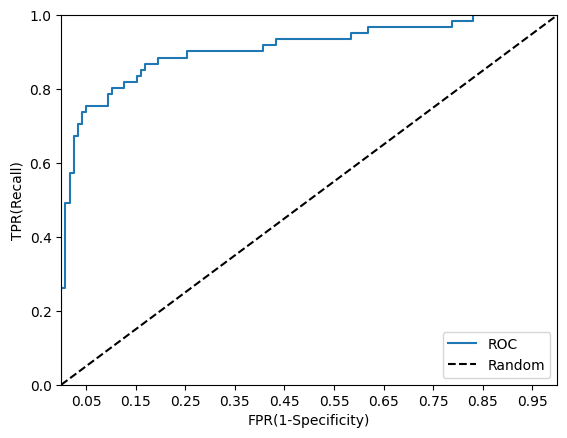

In [56]:
def roc_curve_plot(y_test,pred_proba_c1):
    fprs,tprs,thresholds=roc_curve(y_test,pred_proba_c1)
    plt.plot(fprs,tprs,label='ROC')
    plt.plot([0,1],[0,1],'k--',label='Random')
    start,end=plt.xlim()
    plt.xticks(np.round(np.arange(start,end,0.1),2))
    plt.xlim(0,1);plt.ylim(0,1)
    plt.xlabel('FPR(1-Specificity)');plt.ylabel('TPR(Recall)')
    plt.legend()

roc_curve_plot(y_test,pred_proba[:,1])

In [58]:
from sklearn.metrics import roc_auc_score
pred_proba=lr_clf.predict_proba(X_test)[:,1]
roc_score=roc_auc_score(y_test,pred_proba)
print('ROC AUC값:{0:.4f}'.format(roc_score))

ROC AUC값:0.9087


In [64]:
def get_clf_eval(y_test,pred=None,pred_proba=None):
    confusion=confusion_matrix(y_test,pred)
    accuracy=accuracy_score(y_test,pred)
    precision=precision_score(y_test,pred)
    recall=recall_score(y_test,pred)
    f1=f1_score(y_test,pred)
    roc_auc=roc_auc_score(y_test,pred_proba)
    print('오차행렬')
    print(confusion)
    print('정확도:{0:.4f},정밀도:{1:.4f},재현율:{2:.4f},\F1:{3:.4f}'.format(accuracy,precision,recall,f1,roc_auc))